In [24]:
import json
import pandas as pd
import joblib


In [25]:
rf = joblib.load("fp_confidence_random_forest.pkl")
print("✅ FP confidence model loaded")


✅ FP confidence model loaded


In [26]:
with open("Test//scan_105_vulnerabilities.json", "r") as f:
    scan_data = json.load(f)

print(f"Total findings in scan 105: {len(scan_data)}")


Total findings in scan 105: 1489


In [27]:
# Normalize vulnerability names helper
def normalize_name(name):
    return name.lower().strip()


In [28]:
# Header / configuration related vulnerabilities
header_vulns = [
    "missing_security_header",
    "missing anti-clickjacking header",
    "content security policy (csp) header not set",
    "missing content-security-policy header",
    "strict-transport-security header not set",
    "strict-transport-security missing max-age (non-compliant with spec)",
    "missing hsts header",
    "x-content-type-options header missing",
    "missing x-content-type-options header",
    "missing x-frame-options header",
    "multiple x-frame-options header entries",
    "missing x-xss-protection header",
    "missing referrer-policy header",
    "x-aspnet-version response header",
    "server leaks information via \"x-powered-by\" http response header field(s)",
    "server leaks version information via \"server\" http response header field",
    "permissive cors policy",
    "csp: notices",
    "csp: wildcard directive",
    "csp: style-src unsafe-inline",
    "csp: script-src unsafe-inline",
    "csp: script-src unsafe-eval",
    "csp: failure to define directive with no fallback"
]

HEADER_VULNS = set(normalize_name(v) for v in header_vulns)


In [29]:
# Injection / exploit-based vulnerabilities
injection_vulns = [
    "sql injection",
    "sql injection - mysql",
    "sql injection - mysql (time based)",
    "sql injection - sqlite (time based)",
    "sql injection - mssql (time based)",
    "cross site scripting (reflected)",
    "cross site scripting (dom based)",
    "cross site scripting (persistent)",
    "xslt injection",
    "format string error",
    "session id in url rewrite"
]

INJECTION_VULNS = set(normalize_name(v) for v in injection_vulns)


In [30]:
print("Header vulns:", len(HEADER_VULNS))
print("Injection vulns:", len(INJECTION_VULNS))


Header vulns: 23
Injection vulns: 11


In [31]:
def extract_features(vuln):
    name = vuln.get("name", "").lower().strip()
    evidence = vuln.get("evidence")

    return {
        "has_evidence": 0 if evidence in [None, "", "Not Applicable"] else 1,
        "is_header_issue": int(name in HEADER_VULNS),
        "is_injection": int(name in INJECTION_VULNS)
    }


In [32]:
scan_data

[{'id': 100299,
  'scan_id': 105,
  'name': 'missing_security_header',
  'description': 'Add Strict-Transport-Security header for better security',
  'severity': 'medium',
  'url': 'https://gourmetfoods.pk/',
  'parameter': '',
  'evidence': '',
  'confidence': 1.0,
  'remediation': '',
  'plugin_id': None,
  'source': None,
  'category': None,
  'cwe_id': None,
  'wasc_id': None,
  'attack': None,
  'other_info': None,
  'created_at': '2025-12-16 09:29:20.807383+00:00'},
 {'id': 100300,
  'scan_id': 105,
  'name': 'information_disclosure',
  'description': 'Debug information: 1 instances found',
  'severity': 'low',
  'url': 'https://gourmetfoods.pk/',
  'parameter': '',
  'evidence': "{'type': 'Debug information', 'count': 1, 'examples': ['debug']}",
  'confidence': 1.0,
  'remediation': '',
  'plugin_id': None,
  'source': None,
  'category': None,
  'cwe_id': None,
  'wasc_id': None,
  'attack': None,
  'other_info': None,
  'created_at': '2025-12-16 09:29:20.835513+00:00'},
 {'id'

In [33]:
results = []

for vuln in scan_data:
    features = extract_features(vuln)
    X = pd.DataFrame([features])

    fp_confidence = rf.predict_proba(X)[0][1]

    vuln_result = {
        **vuln,
        **features,
        "fp_confidence": round(fp_confidence, 3)
    }

    results.append(vuln_result)


In [34]:
df_results = pd.DataFrame(results)
df_results.head()


,id,scan_id,name,description,severity,url,parameter,evidence,confidence,remediation,...,category,cwe_id,wasc_id,attack,other_info,created_at,has_evidence,is_header_issue,is_injection,fp_confidence
0,100299,105,missing_security_header,Add Strict-Transport-Security header for bette...,medium,https://gourmetfoods.pk/,,,1.0,,...,None,None,None,None,None,2025-12-16 09:29:20.807383+00:00,0,1,0,1.0
1,100300,105,information_disclosure,Debug information: 1 instances found,low,https://gourmetfoods.pk/,,"{'type': 'Debug information', 'count': 1, 'exa...",1.0,,...,None,None,None,None,None,2025-12-16 09:29:20.835513+00:00,1,0,0,0.0
2,100301,105,Unknown Vulnerability,No description available,medium,https://gourmetfoods.pk/,,,1.0,,...,None,None,None,None,None,2025-12-16 09:29:20.861476+00:00,0,0,0,0.0
3,100302,105,Re-examine Cache-control Directives,The cache-control header has not been set prop...,info,https://gourmetfoods.pk/robots.txt,cache-control,,0.5,"For secure content, ensure the cache-control H...",...,Active Vulnerability,525,13,,,2025-12-16 10:08:05.555603+00:00,0,0,0,0.0
4,100303,105,Content Security Policy (CSP) Header Not Set,Content Security Policy (CSP) is an added laye...,medium,https://gourmetfoods.pk/sitemap.xml,,,0.9,"Ensure that your web server, application serve...",...,Active Vulnerability,693,15,,,2025-12-16 10:08:05.749764+00:00,0,1,0,1.0


In [35]:
THRESHOLD = 0.7

df_results["fp_filtered"] = (df_results["fp_confidence"] >= THRESHOLD).astype(int)


In [36]:
total_alerts = len(df_results)
filtered_alerts = df_results["fp_filtered"].sum()

print(f"Total alerts: {total_alerts}")
print(f"Filtered as likely FP: {filtered_alerts}")
print(f"FP Reduction: {(filtered_alerts / total_alerts) * 100:.2f}%")


Total alerts: 1489
Filtered as likely FP: 375
FP Reduction: 25.18%


In [37]:
df_results.groupby("is_injection")["fp_filtered"].mean()


is_injection
0    0.251847
Name: fp_filtered, dtype: float64

In [38]:
pd.crosstab(df_results["severity"], df_results["fp_filtered"], normalize="index") * 100


fp_filtered,0,1
severity,,
high,100.000000,0.000000
info,100.000000,0.000000
low,72.278339,27.721661
medium,8.571429,91.428571


In [39]:
df_results.to_json(
    "scan_105_with_fp_confidence.json",
    orient="records",
    indent=2
)

print("✅ Scan 105 results saved with FP confidence")


✅ Scan 105 results saved with FP confidence


In [40]:
# Load Scan 105 results WITH FP confidence
df = pd.read_json("scan_105_with_fp_confidence.json")

print(f"Data loaded successfully. Total rows: {len(df)}")
df.head()

Data loaded successfully. Total rows: 1489


,id,scan_id,name,description,severity,url,parameter,evidence,confidence,remediation,...,cwe_id,wasc_id,attack,other_info,created_at,has_evidence,is_header_issue,is_injection,fp_confidence,fp_filtered
0,100299,105,missing_security_header,Add Strict-Transport-Security header for bette...,medium,https://gourmetfoods.pk/,,,1.0,,...,NaN,NaN,None,None,2025-12-16 09:29:20.807383+00:00,0,1,0,1,1
1,100300,105,information_disclosure,Debug information: 1 instances found,low,https://gourmetfoods.pk/,,"{'type': 'Debug information', 'count': 1, 'exa...",1.0,,...,NaN,NaN,None,None,2025-12-16 09:29:20.835513+00:00,1,0,0,0,0
2,100301,105,Unknown Vulnerability,No description available,medium,https://gourmetfoods.pk/,,,1.0,,...,NaN,NaN,None,None,2025-12-16 09:29:20.861476+00:00,0,0,0,0,0
3,100302,105,Re-examine Cache-control Directives,The cache-control header has not been set prop...,info,https://gourmetfoods.pk/robots.txt,cache-control,,0.5,"For secure content, ensure the cache-control H...",...,525.0,13.0,,,2025-12-16 10:08:05.555603+00:00,0,0,0,0,0
4,100303,105,Content Security Policy (CSP) Header Not Set,Content Security Policy (CSP) is an added laye...,medium,https://gourmetfoods.pk/sitemap.xml,,,0.9,"Ensure that your web server, application serve...",...,693.0,15.0,,,2025-12-16 10:08:05.749764+00:00,0,1,0,1,1


In [41]:
# Load Scan 105 results WITH FP confidence
df = pd.read_json("scan_105_with_fp_confidence.json")

print(f"Data loaded successfully. Total rows: {len(df)}")
df.head()

Data loaded successfully. Total rows: 1489


,id,scan_id,name,description,severity,url,parameter,evidence,confidence,remediation,...,cwe_id,wasc_id,attack,other_info,created_at,has_evidence,is_header_issue,is_injection,fp_confidence,fp_filtered
0,100299,105,missing_security_header,Add Strict-Transport-Security header for bette...,medium,https://gourmetfoods.pk/,,,1.0,,...,NaN,NaN,None,None,2025-12-16 09:29:20.807383+00:00,0,1,0,1,1
1,100300,105,information_disclosure,Debug information: 1 instances found,low,https://gourmetfoods.pk/,,"{'type': 'Debug information', 'count': 1, 'exa...",1.0,,...,NaN,NaN,None,None,2025-12-16 09:29:20.835513+00:00,1,0,0,0,0
2,100301,105,Unknown Vulnerability,No description available,medium,https://gourmetfoods.pk/,,,1.0,,...,NaN,NaN,None,None,2025-12-16 09:29:20.861476+00:00,0,0,0,0,0
3,100302,105,Re-examine Cache-control Directives,The cache-control header has not been set prop...,info,https://gourmetfoods.pk/robots.txt,cache-control,,0.5,"For secure content, ensure the cache-control H...",...,525.0,13.0,,,2025-12-16 10:08:05.555603+00:00,0,0,0,0,0
4,100303,105,Content Security Policy (CSP) Header Not Set,Content Security Policy (CSP) is an added laye...,medium,https://gourmetfoods.pk/sitemap.xml,,,0.9,"Ensure that your web server, application serve...",...,693.0,15.0,,,2025-12-16 10:08:05.749764+00:00,0,1,0,1,1


In [42]:
before_count = len(df)

after_count = len(df[df["fp_filtered"] == 0])

filtered_count = len(df[df["fp_filtered"] == 1])

print(f"Before ML: {before_count} alerts")
print(f"After ML: {after_count} alerts")
print(f"Filtered: {filtered_count} alerts")
print(f"Reduction: {(filtered_count / before_count) * 100:.2f}%")


Before ML: 1489 alerts
After ML: 1114 alerts
Filtered: 375 alerts
Reduction: 25.18%


In [43]:
# Alerts BEFORE ML (all findings)
before_df = df.copy()

# Alerts AFTER ML (kept findings)
after_df = df[df["fp_filtered"] == 0]

# Alerts FILTERED by ML (likely FP)
filtered_df = df[df["fp_filtered"] == 1]

print(f"Before ML: {len(before_df)}")
print(f"After ML: {len(after_df)}")
print(f"Filtered: {len(filtered_df)}")


Before ML: 1489
After ML: 1114
Filtered: 375


In [44]:
from IPython.display import display, HTML

def display_with_scroll(df, title, height=300):
    display(HTML(f"<h4>{title}</h4>"))
    display(HTML(
        df.to_html(index=False)
        .replace(
            "<table",
            f"<table style='display:block; max-height:{height}px; overflow-y:auto; border:1px solid #ccc;'"
        )
    ))


In [45]:
display_with_scroll(
    before_df[[
        "name",
        "severity",
        "url",
        "has_evidence",
        "is_header_issue",
        "fp_confidence"
    ]],
    title="Before ML – All Alerts"
)


name,severity,url,has_evidence,is_header_issue,fp_confidence
missing_security_header,medium,https://gourmetfoods.pk/,0,1,1
information_disclosure,low,https://gourmetfoods.pk/,1,0,0
Unknown Vulnerability,medium,https://gourmetfoods.pk/,0,0,0
Re-examine Cache-control Directives,info,https://gourmetfoods.pk/robots.txt,0,0,0
Content Security Policy (CSP) Header Not Set,medium,https://gourmetfoods.pk/sitemap.xml,0,1,1
"Server Leaks Version Information via ""Server"" HTTP Response Header Field",low,https://gourmetfoods.pk/robots.txt,1,1,0
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/robots.txt,0,1,1
"Server Leaks Version Information via ""Server"" HTTP Response Header Field",low,https://gourmetfoods.pk/sitemap.xml,1,1,0
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/sitemap.xml,0,1,1
Re-examine Cache-control Directives,info,https://gourmetfoods.pk/,1,0,0


In [46]:
display_with_scroll(
    after_df[[
        "name",
        "severity",
        "url",
        "has_evidence",
        "is_header_issue",
        "fp_confidence"
    ]],
    title="After ML – Retained Alerts"
)


name,severity,url,has_evidence,is_header_issue,fp_confidence
information_disclosure,low,https://gourmetfoods.pk/,1,0,0
Unknown Vulnerability,medium,https://gourmetfoods.pk/,0,0,0
Re-examine Cache-control Directives,info,https://gourmetfoods.pk/robots.txt,0,0,0
"Server Leaks Version Information via ""Server"" HTTP Response Header Field",low,https://gourmetfoods.pk/robots.txt,1,1,0
"Server Leaks Version Information via ""Server"" HTTP Response Header Field",low,https://gourmetfoods.pk/sitemap.xml,1,1,0
Re-examine Cache-control Directives,info,https://gourmetfoods.pk/,1,0,0
Cookie No HttpOnly Flag,low,https://gourmetfoods.pk/,1,0,0
Cookie without SameSite Attribute,low,https://gourmetfoods.pk/,1,0,0
Cookie Without Secure Flag,low,https://gourmetfoods.pk/,1,0,0
Re-examine Cache-control Directives,info,https://gourmetfoods.pk/login,1,0,0


In [47]:
display_with_scroll(
    filtered_df[[
        "name",
        "severity",
        "url",
        "has_evidence",
        "is_header_issue",
        "fp_confidence"
    ]],
    title="Filtered Alerts – Likely False Positives"
)


name,severity,url,has_evidence,is_header_issue,fp_confidence
missing_security_header,medium,https://gourmetfoods.pk/,0,1,1
Content Security Policy (CSP) Header Not Set,medium,https://gourmetfoods.pk/sitemap.xml,0,1,1
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/robots.txt,0,1,1
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/sitemap.xml,0,1,1
Content Security Policy (CSP) Header Not Set,medium,https://gourmetfoods.pk/,0,1,1
Content Security Policy (CSP) Header Not Set,medium,https://gourmetfoods.pk/login,0,1,1
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/,0,1,1
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/login,0,1,1
Content Security Policy (CSP) Header Not Set,medium,https://gourmetfoods.pk/shop/login,0,1,1
Strict-Transport-Security Header Not Set,low,https://gourmetfoods.pk/shop/login,0,1,1


In [48]:
comparison_df = pd.DataFrame({
    "Before ML": before_df["name"].value_counts(),
    "After ML": after_df["name"].value_counts()
}).fillna(0).astype(int)

display_with_scroll(
    comparison_df.reset_index().rename(columns={"index": "Vulnerability Name"}),
    title="Before vs After ML – Vulnerability Counts",
    height=400
)


name,Before ML,After ML
Application Error Disclosure,2,2
Authentication Request Identified,6,6
CSP: Failure to Define Directive with No Fallback,1,1
CSP: Wildcard Directive,1,1
CSP: style-src unsafe-inline,1,1
Content Security Policy (CSP) Header Not Set,127,0
Cookie No HttpOnly Flag,100,100
Cookie Without Secure Flag,99,99
Cookie with SameSite Attribute None,1,1
Cookie without SameSite Attribute,99,99


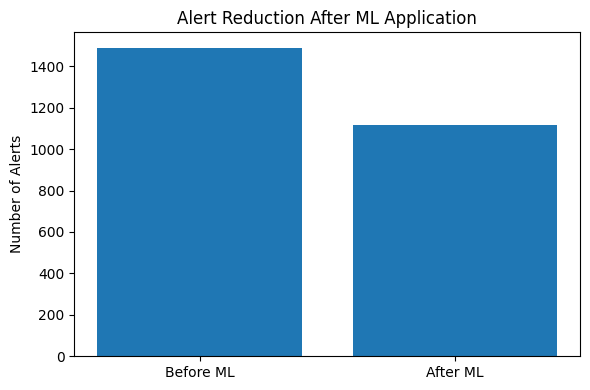

/home/hannan-ali/Dataset/alert_reduction_before_after_ml.png

In [57]:
import matplotlib.pyplot as plt
from IPython.display import FileLink

labels = ["Before ML", "After ML"]
values = [len(before_df), len(after_df)]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Number of Alerts")
plt.title("Alert Reduction After ML Application")
plt.tight_layout()

# Save figure
plt.savefig("alert_reduction_before_after_ml.png", dpi=300, bbox_inches="tight")
plt.show()

# Download link
FileLink("alert_reduction_before_after_ml.png")


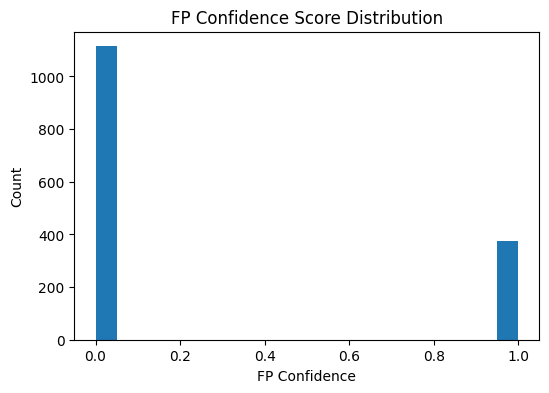

In [53]:
plt.figure(figsize=(6,4))
plt.hist(df["fp_confidence"], bins=20)
plt.xlabel("FP Confidence")
plt.ylabel("Count")
plt.title("FP Confidence Score Distribution")
plt.show()


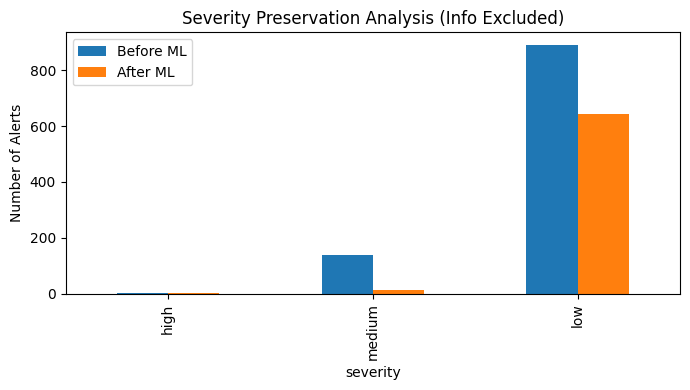

In [58]:
# Exclude 'info' severity
df_no_info = df[df["severity"].isin(["high", "medium", "low"])]

severity_before = df_no_info["severity"].value_counts()
severity_after = df_no_info[df_no_info["fp_filtered"] == 0]["severity"].value_counts()

severity_df = (
    pd.DataFrame({
        "Before ML": severity_before,
        "After ML": severity_after
    })
    .fillna(0)
)

# Ensure consistent ordering
severity_df = severity_df.reindex(["high", "medium", "low"])

severity_df.plot(kind="bar", figsize=(7,4))
plt.ylabel("Number of Alerts")
plt.title("Severity Preservation Analysis (Info Excluded)")
plt.tight_layout()

# Save for download
plt.savefig("severity_preservation_no_info.png", dpi=300, bbox_inches="tight")
plt.show()


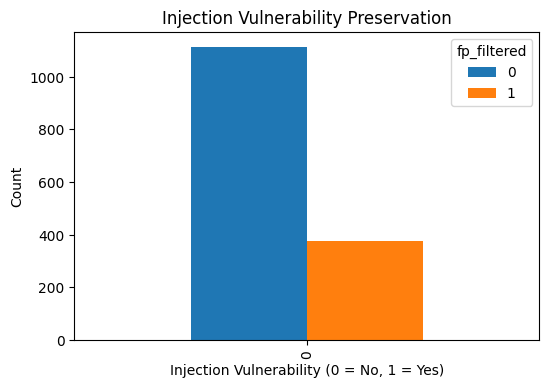

In [55]:
inj_stats = pd.crosstab(df["is_injection"], df["fp_filtered"])

inj_stats.plot(kind="bar", figsize=(6,4))
plt.xlabel("Injection Vulnerability (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Injection Vulnerability Preservation")
plt.show()


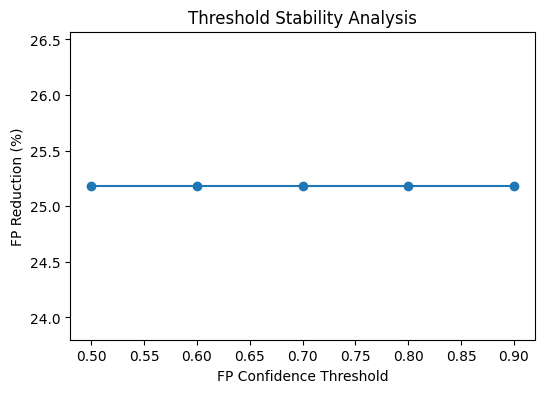

In [56]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
reductions = []

for t in thresholds:
    filtered = (df["fp_confidence"] >= t).sum()
    reductions.append((filtered / len(df)) * 100)

plt.figure(figsize=(6,4))
plt.plot(thresholds, reductions, marker="o")
plt.xlabel("FP Confidence Threshold")
plt.ylabel("FP Reduction (%)")
plt.title("Threshold Stability Analysis")
plt.show()
